# Trần Minh Khoa - 20235121

# Bài 2: Bài toán XOR — Neural Network 1 Hidden Layer

## Câu 1 — Phương trình Forward

### 1. Tham số (Parameters)
Mạng gồm 2 tầng có trọng số:
- **Hidden layer:** - Ma trận trọng số: $W^{(2)} \in \mathbb{R}^{2 \times 2}$
  - Vector bias: $b^{(2)} \in \mathbb{R}^{2 \times 1}$
- **Output layer:** - Ma trận trọng số: $W^{(3)} \in \mathbb{R}^{1 \times 2}$
  - Vector bias: $b^{(3)} \in \mathbb{R}^{1 \times 1}$

### 2. Hàm kích hoạt (Activation Function)
Sử dụng hàm Sigmoid cho tất cả các tầng:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 3. Quá trình Lan truyền tiến (Forward Pass)
Với đầu vào là vector $x \in \mathbb{R}^{2 \times 1}$:

**Tại Hidden Layer:**
- Giá trị trước kích hoạt: $z^{(2)} = W^{(2)}x + b^{(2)}$
- Giá trị sau kích hoạt: $a^{(2)} = \sigma(z^{(2)})$

**Tại Output Layer:**
- Giá trị trước kích hoạt: $z^{(3)} = W^{(3)}a^{(2)} + b^{(3)}$
- Dự đoán đầu ra: $\hat{y} = a^{(3)} = \sigma(z^{(3)})$

---

## Câu 2 — Đạo hàm (Backpropagation)

Mục tiêu là tính đạo hàm của hàm mất mát (Loss) theo các tham số. Ký hiệu sai số tại mỗi tầng là $\delta$.

### 1. Hàm Mất mát (Loss Function)
Sử dụng Binary Cross-Entropy cho bài toán phân loại nhị phân:
$$\mathcal{L} = -\Big[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\Big]$$

### 2. Đạo hàm tại Output Layer
- **Sai số tầng cuối:** $$\delta^{(3)} = \frac{\partial \mathcal{L}}{\partial z^{(3)}} = \hat{y} - y$$
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(3)}} = \delta^{(3)} (a^{(2)})^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(3)}} = \delta^{(3)}$

### 3. Đạo hàm tại Hidden Layer
- **Sai số tầng ẩn:**
  $$\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \sigma'(z^{(2)})$$
  *Trong đó $\odot$ là phép nhân từng phần tử (Hadamard product) và $\sigma'(z) = \sigma(z)(1-\sigma(z))$.*
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)} x^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \delta^{(2)}$

---

## Câu 3 — Giải thuật Lan truyền ngược chi tiết cho bài toán XOR

### Bước 1: Thiết lập đầu vào (Input)
Gán giá trị cho tầng đầu vào $a^{(1)} = x \in \mathbb{R}^{2 \times 1}$. Đây là cặp giá trị XOR (ví dụ: $[0, 1]^T$).

### Bước 2: Lan truyền tiến (Feedforward)
Tính toán lần lượt qua các tầng:
- **Tầng ẩn:** $z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}$ và $a^{(2)} = \sigma(z^{(2)})$, trong đó $z^{(2)}, a^{(2)} \in \mathbb{R}^{2 \times 1}$.
- **Tầng ra:** $z^{(3)} = W^{(3)}a^{(2)} + b^{(3)}$ và $a^{(3)} = \sigma(z^{(3)})$, trong đó $z^{(3)}, a^{(3)} \in \mathbb{R}^{1 \times 1}$.

### Bước 3: Tính sai số tầng đầu ra (Output Error)
Tính vector sai số tại tầng cuối cùng ($L=3$):
$$\delta^{(3)} = (a^{(3)} - y) \in \mathbb{R}^{1 \times 1}$$
*(Với $y$ là nhãn thực tế 0 hoặc 1).*

### Bước 4: Lan truyền ngược sai số (Backpropagate the error)
Tính sai số cho tầng ẩn (tầng $l=2$):
$$\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \sigma'(z^{(2)})$$
- Trong đó: $(W^{(3)})^T \in \mathbb{R}^{2 \times 1}$ nhân với $\delta^{(3)} \in \mathbb{R}^{1 \times 1}$ tạo ra vector $\mathbb{R}^{2 \times 1}$.
- Kết quả $\delta^{(2)} \in \mathbb{R}^{2 \times 1}$ sau phép nhân Hadamard với $\sigma'(z^{(2)})$.

### Bước 5: Kết xuất Gradient (Output)
Tính toán các đạo hàm riêng để cập nhật trọng số:
- **Của tầng 3:** $\frac{\partial \mathcal{L}}{\partial W^{(3)}} = \delta^{(3)} (a^{(2)})^T \in \mathbb{R}^{1 \times 2}$ và $\frac{\partial \mathcal{L}}{\partial b^{(3)}} = \delta^{(3)} \in \mathbb{R}^{1 \times 1}$.
- **Của tầng 2:** $\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)} (a^{(1)})^T \in \mathbb{R}^{2 \times 2}$ và $\frac{\partial \mathcal{L}}{\partial b^{(2)}}$ = $\delta^{(2)} \in \mathbb{R}^{2 \times 1}$.

In [1]:
import numpy as np
import random
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
import os
from sklearn.model_selection import train_test_split

from sklearn.datasets import fetch_openml

In [2]:
### Function for sigmoid activation ###

def sigmoid(z):
    """Compute the sigmoid activation function."""
    a = 1.0 / (1 + np.exp(-z))
    return a

def sigmoid_derivative(z):
    """Compute the derivative of the sigmoid function given the input z."""
    s = sigmoid(z)
    return s * (1 - s)

In [3]:
### Main train function for assignment 2 ###

def train_assignment_2(
        X_data,
        Y_data,
        learning_rate=0.01,
        num_epochs=1000,
):
    """
    Train a 1-hidden layer neural network using Stochastic Gradient Descent.
    Architecture: 2 (Input) -> 2 (Hidden) -> 1 (Output)
    """

    W2 = np.random.rand(2, 2)
    b2 = np.random.rand(2, 1).reshape(-1, 1)

    W3 = np.random.rand(1, 2)
    b3 = np.random.rand(1, 1).reshape(-1, 1)

    for i in range(num_epochs):
        for j in range(len(X_data)):

            # Step 1: Initialize input and target for the current sample
            a1 = X_data[j].reshape(2, 1)
            y_true = Y_data[j].reshape(1, 1)

            # Step 2: Feed Forward Pass
            z2 = np.dot(W2, a1) + b2
            a2 = sigmoid(z2)
            z3 = np.dot(W3, a2) + b3
            a3 = sigmoid(z3)

            # Step 3 & 4: Compute Error and Backpropagate
            delta3 = (a3 - y_true)
            delta2 = np.dot(W3.T, delta3) * sigmoid_derivative(z2)

            # Step 5: Update Parameters using gradients
            dW3 = np.dot(delta3, a2.T)
            db3 = delta3
            dW2 = np.dot(delta2, a1.T)
            db2 = delta2

            # Apply Gradient Descent update rule
            W3 -= learning_rate * dW3
            b3 -= learning_rate * db3
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

    return W2, b2, W3, b3

In [4]:
### Function for prediction ###

def predict(X, W2, b2, W3, b3):
    results = []
    for x in X:
        a1 = x.reshape(2, 1)
        z2 = np.dot(W2, a1) + b2
        a2 = sigmoid(z2)
        z3 = np.dot(W3, a2) + b3
        a3 = sigmoid(z3)
        results.append(a3[0][0])
    return np.array(results)

In [5]:
### Main logic for assignment 2 ###

if __name__ == "__main__":
    X_data = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ])
    Y_data = np.array([
        [0],
        [0],
        [0],
        [1]
    ]).reshape(-1, 1)

    # Train the model
    print("--- Start training (Assignment 2) ---")
    W2, b2, W3, b3 = train_assignment_2(X_data, Y_data, learning_rate=0.1, num_epochs=10000)
    print(f"W2: {W2}\nb2: {b2}\nW3: {W3}\nb3: {b3}")

    # Testing
    print("\n--- Testing ---")
    predictions = predict(X_data, W2, b2, W3, b3)

    for j in range(len(X_data)):
        print(f"Input: {X_data[j]} -> Target: {Y_data[j][0]} -> Dự đoán: {predictions[j]:.4f}")

--- Start training (Assignment 2) ---
W2: [[-3.23034429 -3.26596807]
 [ 4.40866396  4.37399957]]
b2: [[ 4.60417978]
 [-6.36426997]]
W3: [[-7.60024417 10.97374643]]
b3: [[-2.53371825]]

--- Testing ---
Input: [0 0] -> Target: 0 -> Dự đoán: 0.0000
Input: [0 1] -> Target: 0 -> Dự đoán: 0.0007
Input: [1 0] -> Target: 0 -> Dự đoán: 0.0007
Input: [1 1] -> Target: 1 -> Dự đoán: 0.9986


---

# Bài 3: Bài toán nhận dạng chữ số MNIST — Neural Network 1 Hidden Layer

## Câu 1 — Phương trình Forward

### 1. Tham số (Parameters)
Mạng gồm 3 tầng (Input $L_1$, Hidden $L_2$, Output $L_3$). Các kích thước ma trận được xác định bởi:
- **Tầng ẩn ($L_2$):** - Ma trận trọng số: $W^{(2)} \in \mathbb{R}^{30 \times 784}$ (Dẫn từ 784 features vào 30 nơ-ron)
  - Vector bias: $b^{(2)} \in \mathbb{R}^{30 \times 1}$
- **Tầng ra ($L_3$):** - Ma trận trọng số: $W^{(3)} \in \mathbb{R}^{10 \times 30}$ (Dẫn từ 30 nơ-ron vào 10 nơ-ron đầu ra)
  - Vector bias: $b^{(3)} \in \mathbb{R}^{10 \times 1}$

### 2. Hàm kích hoạt (Activation Function)
Sử dụng hàm Sigmoid cho tất cả các tầng:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 3. Quá trình Lan truyền tiến (Forward Pass)
Với đầu vào $x \in \mathbb{R}^{784 \times 1}$ (ảnh MNIST đã trải phẳng):

**Tại Tầng 1 (Input Layer):**
- $a^{(1)} = x$

**Tại Tầng 2 (Hidden Layer):**
- $z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}$
- $a^{(2)} = \sigma(z^{(2)})$

**Tại Tầng 3 (Output Layer):**
- $z^{(3)} = W^{(3)}a^{(2)} + b^{(3)}$
- Dự đoán đầu ra: $\hat{y} = a^{(3)} = \sigma(z^{(3)})$ (Vector $10 \times 1$)

---

## Câu 2 — Đạo hàm (Backpropagation)

Ký hiệu sai số tại mỗi tầng là $\delta^{(l)}$.

### 1. Hàm Mất mát (Loss Function)
Sử dụng Mean Squared Error (MSE) hoặc Cross-Entropy. Giả sử sử dụng MSE cho bài tập này:
$$\mathcal{L} = \frac{1}{2} \| y - \hat{y} \|^2$$

### 2. Đạo hàm tại Output Layer ($L_3$)
- **Sai số tầng cuối:** $$\delta^{(3)} = \nabla_a \mathcal{L} \odot \sigma'(z^{(3)}) = (a^{(3)} - y) \odot \sigma'(z^{(3)})$$
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(3)}} = \delta^{(3)} (a^{(2)})^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(3)}} = \delta^{(3)}$

### 3. Đạo hàm tại Hidden Layer ($L_2$)
- **Sai số tầng ẩn:**
  $$\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \sigma'(z^{(2)})$$
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)} (a^{(1)})^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \delta^{(2)}$

---

## Câu 3 — Giải thuật Gradient Descent

Quy trình cập nhật tham số để cực tiểu hóa hàm mất mát:

### Bước 1: Khởi tạo (Initialization)
Khởi tạo ngẫu nhiên $W^{(2)}, W^{(3)}$ (thường dùng phân phối chuẩn $\mathcal{N}(0, 1)$) và khởi tạo $b^{(2)}, b^{(3)}$ bằng 0. Chọn tốc độ học $\eta$.

### Bước 2: Lan truyền tiến (Forward Pass)
Tính toán $a^{(1)}, z^{(2)}, a^{(2)}, z^{(3)}, a^{(3)}$ theo các công thức ở **Câu 1**.

### Bước 3: Tính sai số lan truyền ngược (Backpropagate Error)
- Tính $\delta^{(3)}$ tại tầng ra dựa trên sự chênh lệch với nhãn thực tế $y$ (vector one-hot $10 \times 1$).
- Truyền ngược để tính $\delta^{(2)}$ tại tầng ẩn theo công thức ở **Câu 2**.

### Bước 4: Tính toán Gradient
Xác định các giá trị đạo hàm riêng $\frac{\partial \mathcal{L}}{\partial W}$ và $\frac{\partial \mathcal{L}}{\partial b}$ cho cả hai tầng dựa trên tích ngoài (outer product) giữa sai số $\delta$ và giá trị kích hoạt $a$ của tầng trước đó.

### Bước 5: Cập nhật trọng số (Update Parameters)
Thực hiện cập nhật các tham số theo quy tắc Gradient Descent:
- $W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}$
- $b^{(l)} \leftarrow b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}$
*(Thực hiện cho cả $l=2$ và $l=3$)*

In [6]:
### Function for loading MNIST dataset ###

def load_mnist_dataset(train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    """
    Load MNIST dataset (784 features) using sklearn and split into sets.
    """

    # Load the MNIST dataset
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X_full = mnist.data.astype('float32') / 255.0  # Chuẩn hóa về [0, 1]
    Y_labels = mnist.target.astype(int)

    n_samples = X_full.shape[0]

    # Onehot encoding
    Y_onehot = np.zeros((n_samples, 10), dtype=np.float32)
    Y_onehot[np.arange(n_samples), Y_labels] = 1

    # Split train, val, test dataset
    X_temp, X_test, Y_temp, Y_test = train_test_split(
        X_full, Y_onehot, test_size=test_size, random_state=random_state
    )
    val_relative_size = val_size / (val_size + train_size)
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_temp, Y_temp, test_size=val_relative_size, random_state=random_state
    )

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [7]:
### Function for computing loss ###

def compute_mse_loss(
        X, Y,
        W2, b2, W3, b3
):
    """
    Compute Mean Squared Error (MSE) loss for a given set of inputs and labels.
    """

    total_error = 0
    n_samples = len(X)

    for i in range(n_samples):
        a1 = X[i].reshape(-1, 1)
        y_true = Y[i].reshape(-1, 1)

        a2 = sigmoid(np.dot(W2, a1) + b2)
        a3 = sigmoid(np.dot(W3, a2) + b3)

        error = 0.5 * (np.sum((a3 - y_true) ** 2))
        total_error += error

    return total_error / n_samples

In [8]:
### Main train function for assignment 3 ###

def train_assignment_3(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate=0.01,
        num_epochs=1000,
):
    """
    Train a neural network model for MNIST classification.
    """

    # Initialize weights and biases
    W2 = np.random.randn(30, 784) * 0.01
    b2 = np.random.randn(30, 1).reshape(-1, 1) * 0.01
    W3 = np.random.randn(10, 30) * 0.01
    b3 = np.random.randn(10, 1).reshape(-1, 1) * 0.01

    n_samples = len(X_train)

    train_loss_history = []
    val_loss_history = []

    # Training loop
    for i in range(num_epochs):

        # Shuffle the training data
        indices = np.random.permutation(n_samples)
        X_epoch = X_train[indices]
        Y_epoch = Y_train[indices]

        # Forward pass
        for j in range(n_samples):

            # Step 1: Initialize input and target for the current sample
            a1 = X_epoch[j].reshape(784, 1)
            y_true = Y_epoch[j].reshape(10, 1)

            # Step 2: Feed Forward Pass
            z2 = np.dot(W2, a1) + b2
            a2 = sigmoid(z2)
            z3 = np.dot(W3, a2) + b3
            a3 = sigmoid(z3)

            # Step 3 & 4: Compute Error and Backpropagate
            delta3 = (a3 - y_true) * sigmoid_derivative(z3)
            delta2 = np.dot(W3.T, delta3) * sigmoid_derivative(z2)

            # Step 5: Update Parameters using gradients
            dW3 = np.dot(delta3, a2.T)
            db3 = delta3
            dW2 = np.dot(delta2, a1.T)
            db2 = delta2

            # Apply Gradient Descent update rule
            W3 -= learning_rate *dW3
            b3 -= learning_rate *db3
            W2 -= learning_rate *dW2
            b2 -= learning_rate *db2

        # Compute loss and update loss history
        train_loss = compute_mse_loss(X_epoch, Y_epoch, W2, b2, W3, b3)
        val_loss = compute_mse_loss(X_val, Y_val, W2, b2, W3, b3)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

    return W3, b3, W2, b2, train_loss_history, val_loss_history

In [9]:
### Function for plotting loss history and parameter space ###

def plot_loss_history(
        train_loss_history,
        val_loss_history
):
    """
    Plot the training and validation loss over time.
    """

    plt.figure(figsize=(10, 6))
    plt.plot(train_loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def plot_parameter_space_pca(
        X, Y,
        sample_size=1000
):
    """
    Plot the parameter space of PCA for a given dataset.
    """

    indices = random.sample(range(len(X)), sample_size)
    X_sample = X[indices]
    Y_sample = Y[indices]

    y_labels = np.argmax(Y_sample, axis=1)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_sample)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y_labels,
        cmap="tab10",
        alpha=0.7,
        edgecolors="white",
        linewidths=0.5,
    )

    plt.colorbar(scatter, label="Class Label")
    plt.title("MNIST Dataset (2D PCA)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

def plot_parameter_space_tsne(X, Y, sample_size=20000):
    """
    Visualizes high-dimensional data in 2D using t-SNE.
    t-SNE is much better at creating distinct clusters than PCA.
    """
    print(f"--- Running t-SNE on {sample_size} samples (This may take a moment...) ---")

    # 1. Non-repetitive sampling
    indices = random.sample(range(len(X)), sample_size)
    X_sample = X[indices]
    Y_sample = Y[indices]
    y_labels = np.argmax(Y_sample, axis=1)

    # 2. t-SNE Configuration
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_sample)

    # 3. Plotting
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=y_labels,
        cmap="tab10",
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
    )

    plt.colorbar(scatter, label="Class Label", ticks=range(10))
    plt.title("MNIST Dataset (2D t-SNE)")
    plt.xlabel("t-SNE feature 1")
    plt.ylabel("t-SNE feature 2")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

--- Loading and Preprocessing Data ---
--- Starting Training ---
--- Testing the Model ---
Test Loss: 0.0584
--- Plotting Loss History ---


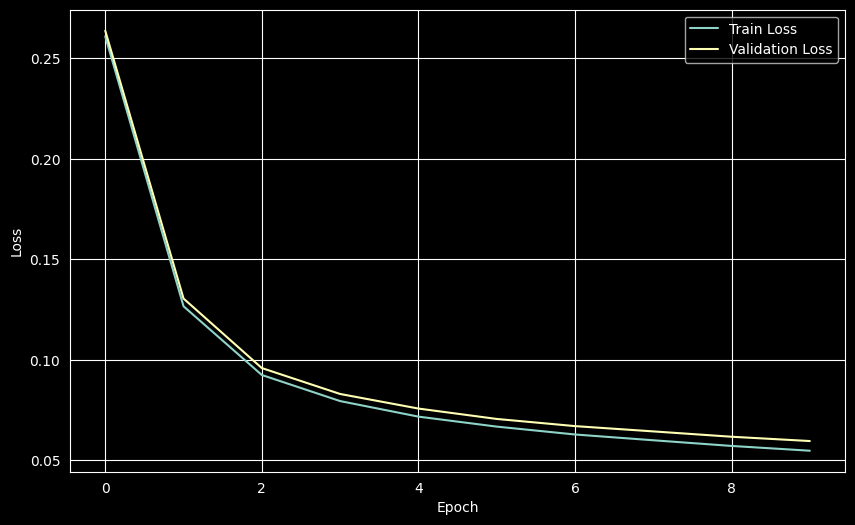

--- Visualizing Parameter Space via PCA ---


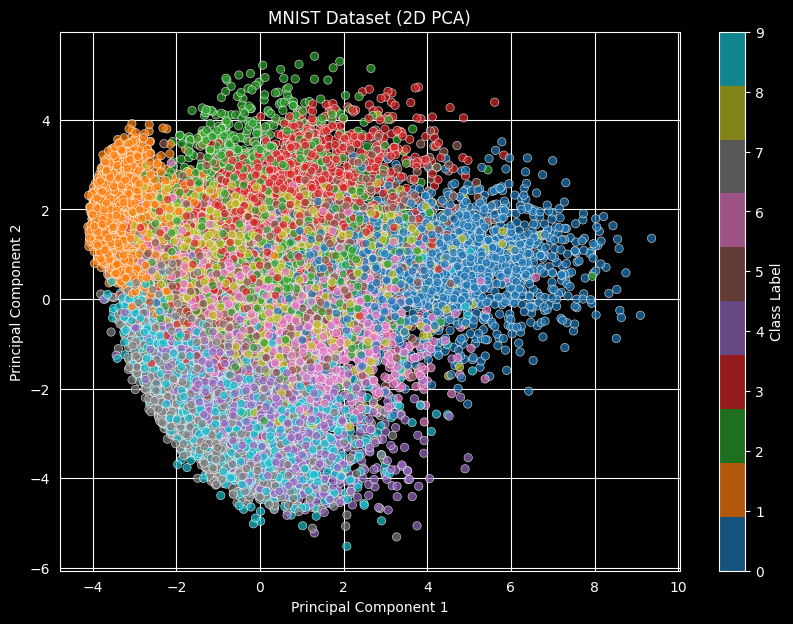

--- Visualizing Parameter Space via t-SNE ---
--- Running t-SNE on 20000 samples (This may take a moment...) ---


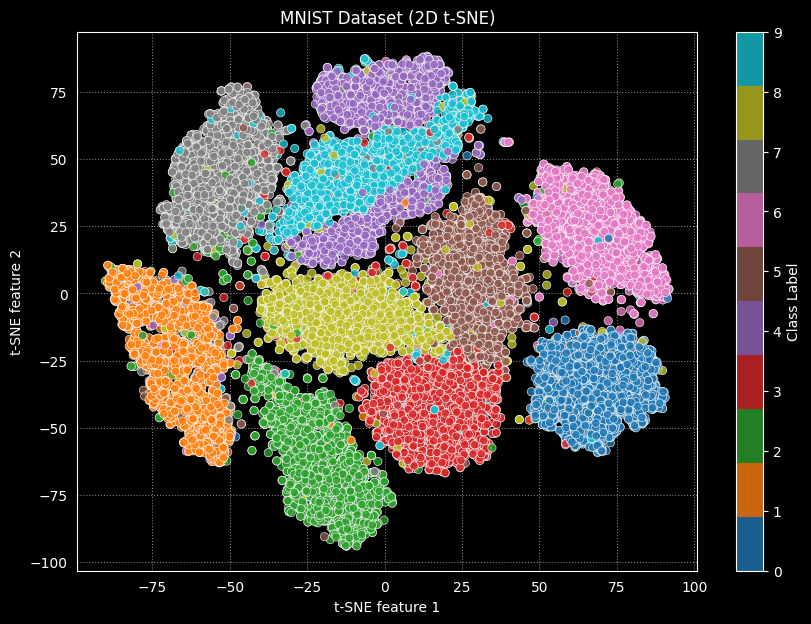

--- Execution Completed Successfully ---


In [10]:
### Main logic for assignment 3 ###

if __name__ == "__main__":
    # 1. Load the MNIST dataset
    print("--- Loading and Preprocessing Data ---")
    X_train, Y_train, X_val, Y_val, X_test, Y_test = load_mnist_dataset(
        train_size=0.7,
        val_size=0.15,
        test_size=0.15
    )

    # 2. Train the Model
    print("--- Starting Training ---")
    W3, b3, W2, b2, train_loss_history, val_loss_history = train_assignment_3(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate=0.01,
        num_epochs=10
    )

    # 3. Test the model
    print("--- Testing the Model ---")
    test_loss = compute_mse_loss(X_test, Y_test, W2, b2, W3, b3)
    print(f"Test Loss: {test_loss:.4f}")


    # 4. Plot Loss History
    print("--- Plotting Loss History ---")
    plot_loss_history(train_loss_history, val_loss_history)

    # 5. Plot Parameter Space (2D PCA)
    print("--- Visualizing Parameter Space via PCA ---")
    plot_parameter_space_pca(X_train, Y_train, sample_size=20000)

    print("--- Visualizing Parameter Space via t-SNE ---")
    plot_parameter_space_tsne(X_train, Y_train, sample_size=20000)

    print("--- Execution Completed Successfully ---")

# Bài 4: Bài toán phân loại ảnh CIFAR-10 — Neural Network 1 Hidden Layer

## Câu 1 — Phương trình Forward

### 1. Tham số (Parameters)
Ảnh CIFAR-10 có kích thước $32 \times 32$ với 3 kênh màu (RGB). Tổng số đặc trưng đầu vào là $32 \times 32 \times 3 = 3072$.
- **Tầng ẩn ($L_2$):** Giả sử cấu hình tương tự bài 3 với 30 nơ-ron.
  - Ma trận trọng số: $W^{(2)} \in \mathbb{R}^{30 \times 3072}$
  - Vector bias: $b^{(2)} \in \mathbb{R}^{30 \times 1}$
- **Tầng ra ($L_3$):** Có 10 lớp đối tượng (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).
  - Ma trận trọng số: $W^{(3)} \in \mathbb{R}^{10 \times 30}$
  - Vector bias: $b^{(3)} \in \mathbb{R}^{10 \times 1}$

### 2. Hàm kích hoạt (Activation Function)
Sử dụng hàm Sigmoid cho cả tầng ẩn và tầng ra:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 3. Quá trình Lan truyền tiến (Forward Pass)
Với đầu vào $x \in \mathbb{R}^{3072 \times 1}$ (ảnh đã trải phẳng và chuẩn hóa):

**Tại Tầng 2 (Hidden Layer):**
- $z^{(2)} = W^{(2)}x + b^{(2)}$
- $a^{(2)} = \sigma(z^{(2)})$

**Tại Tầng 3 (Output Layer):**
- $z^{(3)} = W^{(3)}a^{(2)} + b^{(3)}$
- Dự đoán đầu ra: $\hat{y} = a^{(3)} = \sigma(z^{(3)})$ (Vector xác suất $10 \times 1$)

---

## Câu 2 — Đạo hàm (Backpropagation)

Theo yêu cầu chung của các bài tập trong slide (sử dụng Cross-Entropy), các công thức đạo hàm như sau:

### 1. Hàm Mất mát (Cross-Entropy Loss)
$$\mathcal{L} = -\sum_{i=1}^{10} y_i \log(\hat{y}_i)$$
*Trong đó $y$ là vector nhãn dạng one-hot.*

### 2. Đạo hàm tại Output Layer ($L_3$)
- **Sai số tầng cuối:** $$\delta^{(3)} = a^{(3)} - y$$
  *(Đây là kết quả đạo hàm kết hợp Cross-Entropy và Sigmoid)*
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(3)}} = \delta^{(3)} (a^{(2)})^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(3)}} = \delta^{(3)}$

### 3. Đạo hàm tại Hidden Layer ($L_2$)
- **Sai số tầng ẩn:**
  $$\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \sigma'(z^{(2)})$$
  Với $\sigma'(z^{(2)}) = a^{(2)} \odot (1 - a^{(2)})$.
- **Gradient của tham số:**
  - $\frac{\partial \mathcal{L}}{\partial W^{(2)}} = \delta^{(2)} x^T$
  - $\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \delta^{(2)}$

---

## Câu 3 — Giải thuật Gradient Descent

Quy trình cập nhật trọng số để tối ưu mô hình:

### Bước 1: Khởi tạo (Initialization)
Khởi tạo trọng số $W^{(2)}, W^{(3)}$ bằng phân phối chuẩn (ví dụ: Xavier Initialization để phù hợp với input lớn 3072). Khởi tạo $b$ bằng 0. Chọn tốc độ học $\eta$.

### Bước 2: Lan truyền tiến (Forward Pass)
Tính toán các giá trị $a^{(2)}$ và $a^{(3)}$ theo công thức tại **Câu 1**. Lưu trữ các giá trị $z$ và $a$ để phục vụ tính đạo hàm.

### Bước 3: Tính sai số lan truyền ngược (Backpropagate Error)
- Chuyển nhãn số thành vector one-hot.
- Tính $\delta^{(3)}$ dựa trên chênh lệch dự đoán và nhãn thực tế.
- Truyền ngược sai số về tầng ẩn để tính $\delta^{(2)}$.

### Bước 4: Tính toán Gradient
Xác định độ dốc (gradient) cho tất cả $W$ và $b$ ở cả hai tầng dựa trên các giá trị $\delta$ đã tính.

### Bước 5: Cập nhật tham số (Update Parameters)
Cập nhật theo công thức:
- $W^{(l)} = W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}$
- $b^{(l)} = b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}$

---

In [11]:
### Function for loading CIFAR-10 dataset ###

def unpickle(file_path):
    """
    Load a pickle file and return the data as a dictionary.
    """
    with open(file_path, "rb") as of:
        dict_data = pickle.load(of, encoding="bytes")
    return dict_data

def load_cifar10_dataset(
        train_size=0.7,
        val_size=0.15,
        test_size=0.15,
        random_state=42,
):
    """
    Load CIFAR-10 dataset (32x32x3) and split into train, validation, and test sets.
    """
    X_full = []
    Y_full = []

    # Load and preprocess data for each batch
    for i in range(1, 6):
        file_path = f"./data/cifar_10/cifar-10-batches-py/data_batch_{i}"
        if not os.path.exists(file_path):
            print(f"File {file_path} not found. Skipping...")
        data = unpickle(file_path=file_path)
        X_full.append(data[b'data'])
        Y_full.append(data[b'labels'])

    test_file_path = "./data/cifar_10/cifar-10-batches-py/test_batch"
    if not os.path.exists(test_file_path):
        print(f"File {test_file_path} not found. Skipping...")
    test_data = unpickle(file_path=test_file_path)

    # Concatenate and reshape data
    X_full.append(test_data[b'data'])
    Y_full.append(test_data[b'labels'])

    X_full = np.concatenate(X_full, axis=0)
    Y_full = np.concatenate(Y_full, axis=0)
    n_samples = len(X_full)

    # One-hot encode labels
    Y_onehot = np.zeros(shape=(n_samples, 10), dtype=np.float32)
    Y_onehot[np.arange(n_samples), Y_full] = 1

    # Split data into train, validation, and test sets
    X_temp, X_test, Y_temp, Y_test = train_test_split(
        X_full, Y_onehot, test_size=test_size, random_state=random_state
    )
    val_relative_size = val_size / (val_size + train_size)
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_temp, Y_temp, test_size=val_relative_size, random_state=random_state
    )

    return X_train, Y_train, X_val, Y_val, X_test, Y_test


In [12]:
### Main train function for assignment 4 ###

def train_assignment_4(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate=0.01,
        num_epochs=1000,
        batch_size=128,
):
    """
    Train a neural network model for MNIST classification.
    """

    # Initialize model parameters
    input_size = 32 * 32 * 3
    hidden_size = 30
    output_size = 10

    W2 = np.random.randn(hidden_size, input_size) * 0.01
    b2 = np.random.randn(30, 1).reshape(-1, 1) * 0.01
    W3 = np.random.randn(output_size, hidden_size) * 0.01
    b3 = np.random.randn(10, 1).reshape(-1, 1) * 0.01

    n_samples = len(X_train)

    train_loss_history = []
    val_loss_history = []

    # Training Loop
    for i in range(num_epochs):
        indices = np.random.permutation(n_samples)
        X_epoch = X_train[indices]
        Y_epoch = Y_train[indices]

        for j in range(0, n_samples, batch_size):

            # Step 1: Initialize input and target for the current sample
            X_batch = X_epoch[j : j + batch_size].T
            Y_batch = Y_epoch[j : j + batch_size].T
            curr_size = X_batch.shape[1]

            a1 = X_batch
            y_true = Y_batch

            # Step 2: Feed Forward Pass
            z2 = np.dot(W2, a1) + b2
            a2 = sigmoid(z2)
            z3 = np.dot(W3, a2) + b3
            a3 = sigmoid(z3)

            # Step 3 & 4: Compute Error and Backpropagate
            delta3 = (a3 - y_true) * sigmoid_derivative(z3)
            delta2 = np.dot(W3.T, delta3) * sigmoid_derivative(z2)

            # Step 5: Update Parameters using gradients
            dW3 = np.dot(delta3, a2.T) / curr_size
            db3 = np.sum(delta3, axis=1, keepdims=True) / curr_size
            dW2 = np.dot(delta2, a1.T) / curr_size
            db2 = np.sum(delta2, axis=1, keepdims=True) / curr_size

            # Apply Gradient Descent update rule
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2
            W3 -= learning_rate * dW3
            b3 -= learning_rate * db3

        # Compute loss and update loss history
        train_loss = compute_mse_loss(X_epoch, Y_epoch, W2, b2, W3, b3)
        val_loss = compute_mse_loss(X_val, Y_val, W2, b2, W3, b3)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

    return W3, b3, W2, b2, train_loss_history, val_loss_history

IMPORTANT: sklearn download CIFAR-10 failed, download it manually from https://www.cs.toronto.edu/~kriz/cifar.html
--- Loading and Preprocessing Data ---
--- Starting Training ---
--- Testing the Model ---
Test Loss: 0.4495
--- Plotting Loss History ---


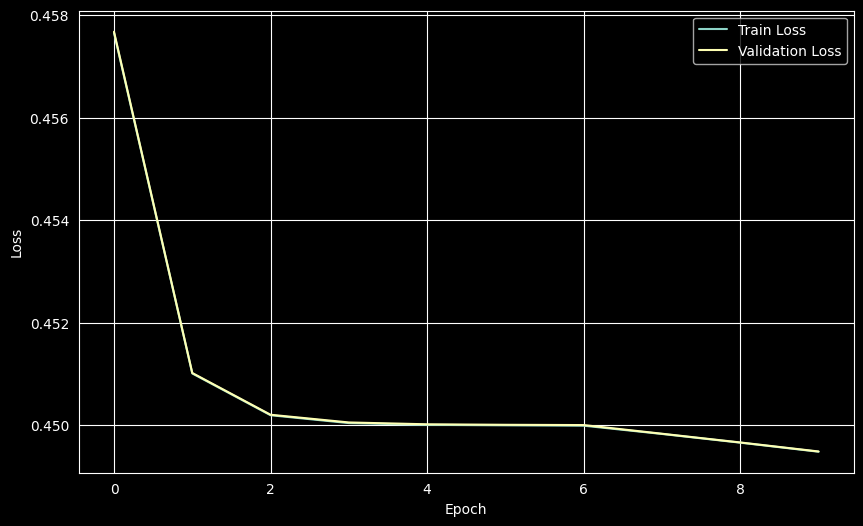

--- Visualizing Parameter Space via PCA ---


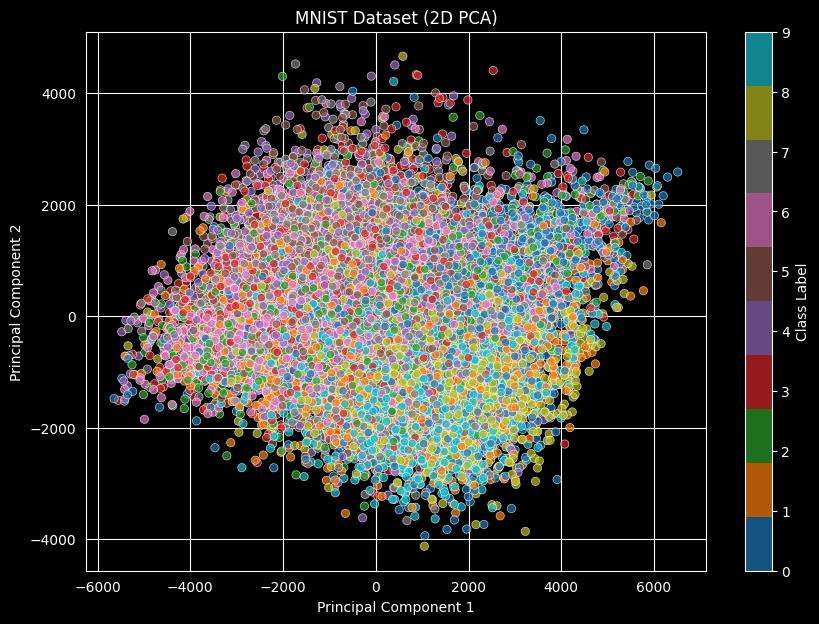

--- Visualizing Parameter Space via t-SNE ---
--- Running t-SNE on 20000 samples (This may take a moment...) ---


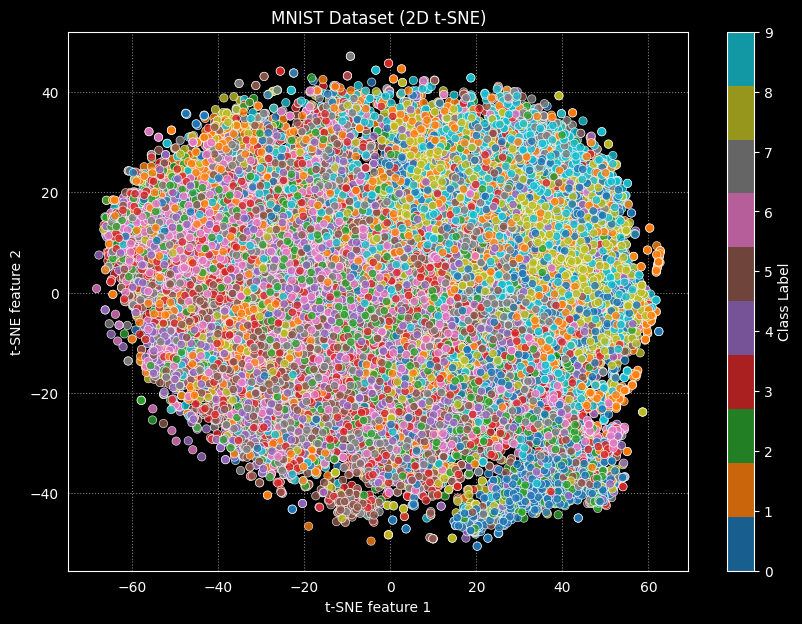

--- Execution Completed Successfully ---


In [13]:
### Main logic for assignment 4 ###

if __name__ == "__main__":
    print("IMPORTANT: sklearn download CIFAR-10 failed, download it manually from https://www.cs.toronto.edu/~kriz/cifar.html")
    # 1. Load the Cifar-10 dataset
    print("--- Loading and Preprocessing Data ---")
    X_train, Y_train, X_val, Y_val, X_test, Y_test = load_cifar10_dataset(
        train_size=0.7,
        val_size=0.15,
        test_size=0.15
    )

    # 2. Train the Model
    print("--- Starting Training ---")
    W3, b3, W2, b2, train_loss_history, val_loss_history = train_assignment_4(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate=0.01,
        num_epochs=10
    )

    # 3. Test the model
    print("--- Testing the Model ---")
    test_loss = compute_mse_loss(X_test, Y_test, W2, b2, W3, b3)
    print(f"Test Loss: {test_loss:.4f}")


    # 4. Plot Loss History
    print("--- Plotting Loss History ---")
    plot_loss_history(train_loss_history, val_loss_history)

    # 5. Plot Parameter Space (2D PCA)
    print("--- Visualizing Parameter Space via PCA ---")
    plot_parameter_space_pca(X_train, Y_train, sample_size=20000)

    print("--- Visualizing Parameter Space via t-SNE ---")
    plot_parameter_space_tsne(X_train, Y_train, sample_size=20000)

    print("--- Execution Completed Successfully ---")